# 岡山市中心部の滞在人口比較

In [10]:
import pandas as pd
import seaborn as sns

In [11]:

w_df = pd.read_csv('area1_month_weekdays.csv', encoding="cp932")
w_df.head()

,Unnamed: 0,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上
0,2018-1,平日,1791.2,1794.1,601.4,527.6,642.2,563.7,581.6,668.8
1,2018-2,平日,1626.6,1586.9,534.6,460.0,574.5,507.7,528.1,608.6
2,2018-3,平日,1903.0,1830.7,630.8,538.3,654.8,584.4,616.5,708.9
3,2018-4,平日,1764.6,1724.6,571.7,507.4,590.0,529.6,558.5,732.1
4,2018-5,平日,1835.4,1771.0,616.5,539.1,608.9,554.8,562.4,724.6


In [12]:
w_df = w_df.drop(["Unnamed: 1"], axis=1)

w_df = w_df.rename(columns={"Unnamed: 0": "ds"})
w_df['ds'] = pd.to_datetime(w_df['ds'])
w_df

,ds,男性,女性,20代,30代,40代,50代,60代,70歳以上
0,2018-01-01,1791.2,1794.1,601.4,527.6,642.2,563.7,581.6,668.8
1,2018-02-01,1626.6,1586.9,534.6,460.0,574.5,507.7,528.1,608.6
2,2018-03-01,1903.0,1830.7,630.8,538.3,654.8,584.4,616.5,708.9
3,2018-04-01,1764.6,1724.6,571.7,507.4,590.0,529.6,558.5,732.1
4,2018-05-01,1835.4,1771.0,616.5,539.1,608.9,554.8,562.4,724.6
...,...,...,...,...,...,...,...,...,...
83,2024-12-01,1505.8,1498.6,615.3,477.5,586.1,482.9,384.5,458.1
84,2025-01-01,1379.4,1384.6,584.5,451.9,522.8,450.5,350.5,403.8
85,2025-02-01,1207.9,1203.9,486.1,387.6,468.4,400.1,308.0,361.6
86,2025-03-01,1385.3,1423.0,573.1,431.2,538.7,461.0,366.6,437.7


In [13]:
pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 79.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=dcd787238ffca70aeca394cea4d6f1c6f9287f461ba4556e6fcc2d07f3931f07
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [14]:
#折れ線グラフを作成
import matplotlib.pyplot as plt

In [15]:
#横持ちのデータを縦持ちに変換
df_melted = w_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
df_melted['ds'] = pd.to_datetime(df_melted['ds'])

df_melted

,ds,Category,Value
0,2018-01-01,男性,1791.2
1,2018-02-01,男性,1626.6
2,2018-03-01,男性,1903.0
3,2018-04-01,男性,1764.6
4,2018-05-01,男性,1835.4
...,...,...,...
699,2024-12-01,70歳以上,458.1
700,2025-01-01,70歳以上,403.8
701,2025-02-01,70歳以上,361.6
702,2025-03-01,70歳以上,437.7


In [16]:
import japanize_matplotlib

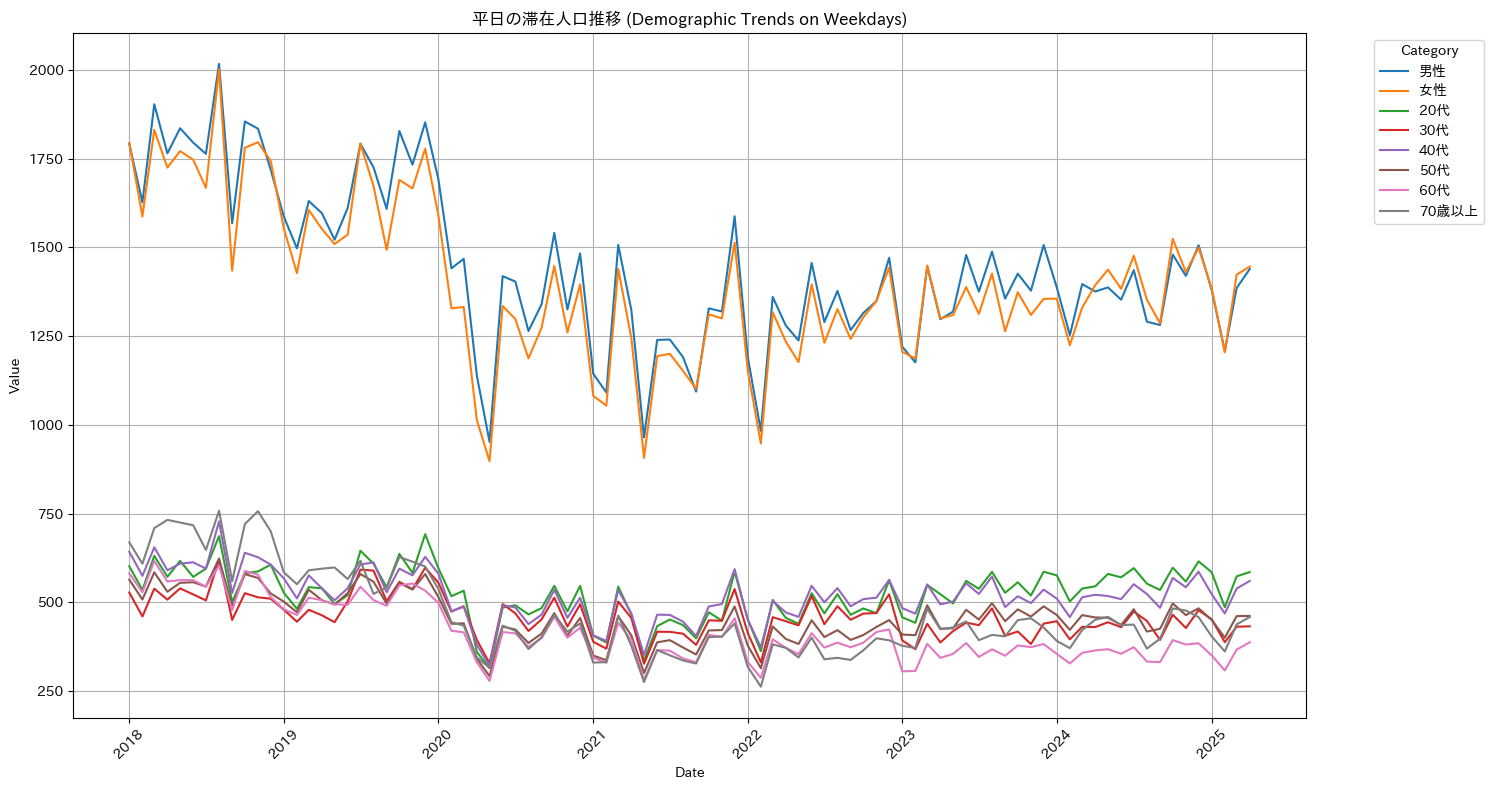

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df_melted_numeric = df_melted[df_melted['Category'] != 'Unnamed: 1'].copy()
df_melted_numeric['Value'] = pd.to_numeric(df_melted_numeric['Value'])

plt.figure(figsize=(15, 8))
sns.lineplot(data=df_melted_numeric, x='ds', y='Value', hue='Category')
plt.title('平日の滞在人口推移 (Demographic Trends on Weekdays)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [18]:

holiday_df = pd.read_csv("area1_month_holidays.csv", encoding="cp932")
h_df = holiday_df
h_df

,Unnamed: 0,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上
0,2018-1,祝休日,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5
1,2018-2,祝休日,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4
2,2018-3,祝休日,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9
3,2018-4,祝休日,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7
4,2018-5,祝休日,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2
...,...,...,...,...,...,...,...,...,...,...
83,2024-12,祝休日,616.8,642.5,284.1,222.8,255.2,189.8,139.5,167.9
84,2025-1,祝休日,597.5,639.8,277.9,213.3,245.2,190.0,141.3,169.5
85,2025-2,祝休日,605.5,663.6,283.3,218.5,251.3,193.8,143.4,178.8
86,2025-3,祝休日,701.3,782.5,327.2,245.9,293.5,236.3,172.8,208.0


In [19]:
h_df = h_df.drop(["Unnamed: 1"], axis=1)

h_df = h_df.rename(columns={"Unnamed: 0": "ds"})
h_df['ds'] = pd.to_datetime(w_df['ds'])

#横持ちのデータを縦持ちに変換
h_df_melted = h_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
h_df_melted['ds'] = pd.to_datetime(h_df_melted['ds'])

h_df_melted

,ds,Category,Value
0,2018-01-01,男性,741.6
1,2018-02-01,男性,705.0
2,2018-03-01,男性,832.1
3,2018-04-01,男性,834.9
4,2018-05-01,男性,846.1
...,...,...,...
699,2024-12-01,70歳以上,167.9
700,2025-01-01,70歳以上,169.5
701,2025-02-01,70歳以上,178.8
702,2025-03-01,70歳以上,208.0


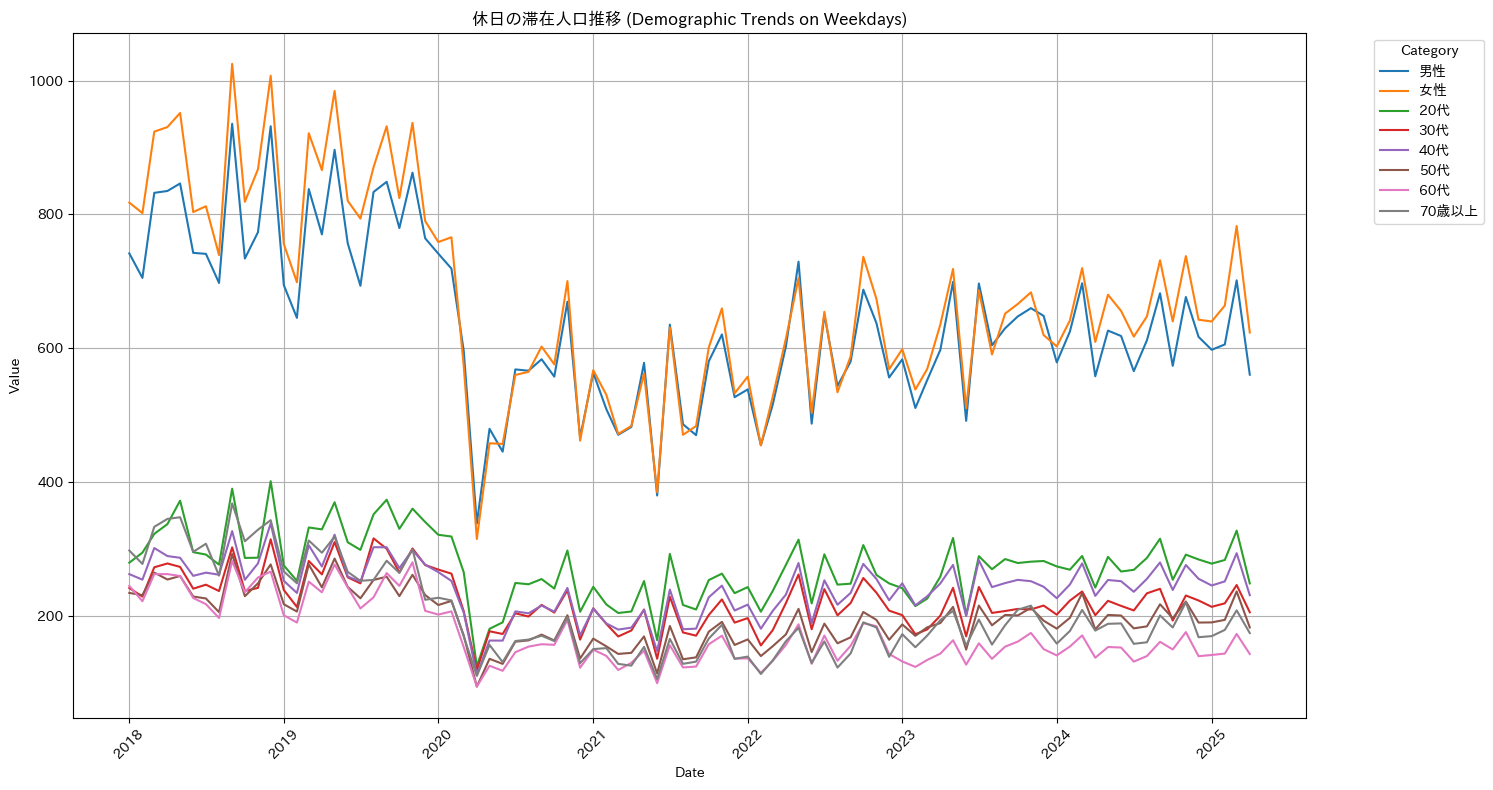

In [20]:
h_df_melted_numeric = h_df_melted[h_df_melted['Category'] != 'Unnamed: 1'].copy()
h_df_melted_numeric['Value'] = pd.to_numeric(h_df_melted_numeric['Value'])

plt.figure(figsize=(15, 8))
sns.lineplot(data=h_df_melted_numeric, x='ds', y='Value', hue='Category')
plt.title('休日の滞在人口推移 (Demographic Trends on Weekdays)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 岡南地域の平日と休日の滞在人口比較

In [21]:
kounan_df = pd.read_csv('kounan_month.csv', encoding="cp932")
kounan_df.head()

,岡南（都市拠点） 滞在人口（男女別・年代別）,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,岡南,NaN,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,NaN,NaN,男性,女性,20代,30代,40代,50代,60代,70歳以上
1,2018年1月,期間全体,468.1,481.3,126.2,132.7,185.2,151.4,199.8,154.2,...,NaN,祝休日,149.9,160.3,40.9,46.3,62.2,51.9,65.5,43.4
2,2018年2月,期間全体,430.7,444.4,116.8,120.7,161.2,142.9,188.2,145.3,...,NaN,祝休日,140.8,140.9,36.1,44.2,54.3,47.3,61.4,38.5
3,2018年3月,期間全体,477.4,516.8,129.5,148,197.3,162.9,202.7,153.7,...,NaN,祝休日,162.8,176.7,43,55.8,67.8,56.1,69.1,47.6
4,2018年4月,期間全体,475.7,583.3,142.8,148.2,176.1,160.6,196.5,234.6,...,NaN,祝休日,169.6,216.2,51.9,59.5,65.4,57.6,66.8,84.7


In [25]:
kounan_df = kounan_df.drop(["Unnamed: 1"], axis=1)

kounan_df = kounan_df.rename(columns={"Unnamed: 0": "ds"})
kounan_df['ds'] = pd.to_datetime(w_df['ds'])
kounan_df

,岡南（都市拠点） 滞在人口（男女別・年代別）,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,ds
0,岡南,男性,女性,20代,30代,40代,50代,60代,70歳以上,NaN,...,NaN,男性,女性,20代,30代,40代,50代,60代,70歳以上,2018-01-01
1,2018年1月,468.1,481.3,126.2,132.7,185.2,151.4,199.8,154.2,NaN,...,祝休日,149.9,160.3,40.9,46.3,62.2,51.9,65.5,43.4,2018-02-01
2,2018年2月,430.7,444.4,116.8,120.7,161.2,142.9,188.2,145.3,NaN,...,祝休日,140.8,140.9,36.1,44.2,54.3,47.3,61.4,38.5,2018-03-01
3,2018年3月,477.4,516.8,129.5,148,197.3,162.9,202.7,153.7,NaN,...,祝休日,162.8,176.7,43,55.8,67.8,56.1,69.1,47.6,2018-04-01
4,2018年4月,475.7,583.3,142.8,148.2,176.1,160.6,196.5,234.6,NaN,...,祝休日,169.6,216.2,51.9,59.5,65.4,57.6,66.8,84.7,2018-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,2024年12月,468.3,521.4,111.8,154.7,175.4,160.4,157.7,229.7,NaN,...,祝休日,141,158.5,34.1,46.4,57.9,49.4,47.4,64.3,2025-01-01
85,2025年1月,443.5,490.1,105.8,144.1,172,150,143.7,218,NaN,...,祝休日,144.9,165.9,37.3,50.2,58.7,51.4,46.1,67.1,2025-02-01
86,2025年2月,398.9,441,97.3,124.4,150.8,140.4,129.5,197.4,NaN,...,祝休日,145.9,157.9,34.5,45.8,61,52.9,44.4,65.2,2025-03-01
87,2025年3月,444,492.5,104.2,140.7,174,154.9,141.2,221.5,NaN,...,祝休日,161.3,177.1,38.2,53.2,68.1,57.2,48.5,73.1,2025-04-01


In [28]:
#折れ線グラフを作成
df_melted_numeric['DayType'] = 'Weekday'
h_df_melted_numeric['DayType'] = 'Holiday'

combined_df = pd.concat([df_melted_numeric, h_df_melted_numeric], ignore_index=True)

print("結合後のデータ")
print(combined_df.head())
print(combined_df.tail())

Combined DataFrame created successfully. Displaying head and tail:
          ds Category   Value  DayType
0 2018-01-01       男性  1791.2  Weekday
1 2018-02-01       男性  1626.6  Weekday
2 2018-03-01       男性  1903.0  Weekday
3 2018-04-01       男性  1764.6  Weekday
4 2018-05-01       男性  1835.4  Weekday
             ds Category  Value  DayType
1403 2024-12-01    70歳以上  167.9  Holiday
1404 2025-01-01    70歳以上  169.5  Holiday
1405 2025-02-01    70歳以上  178.8  Holiday
1406 2025-03-01    70歳以上  208.0  Holiday
1407 2025-04-01    70歳以上  174.1  Holiday


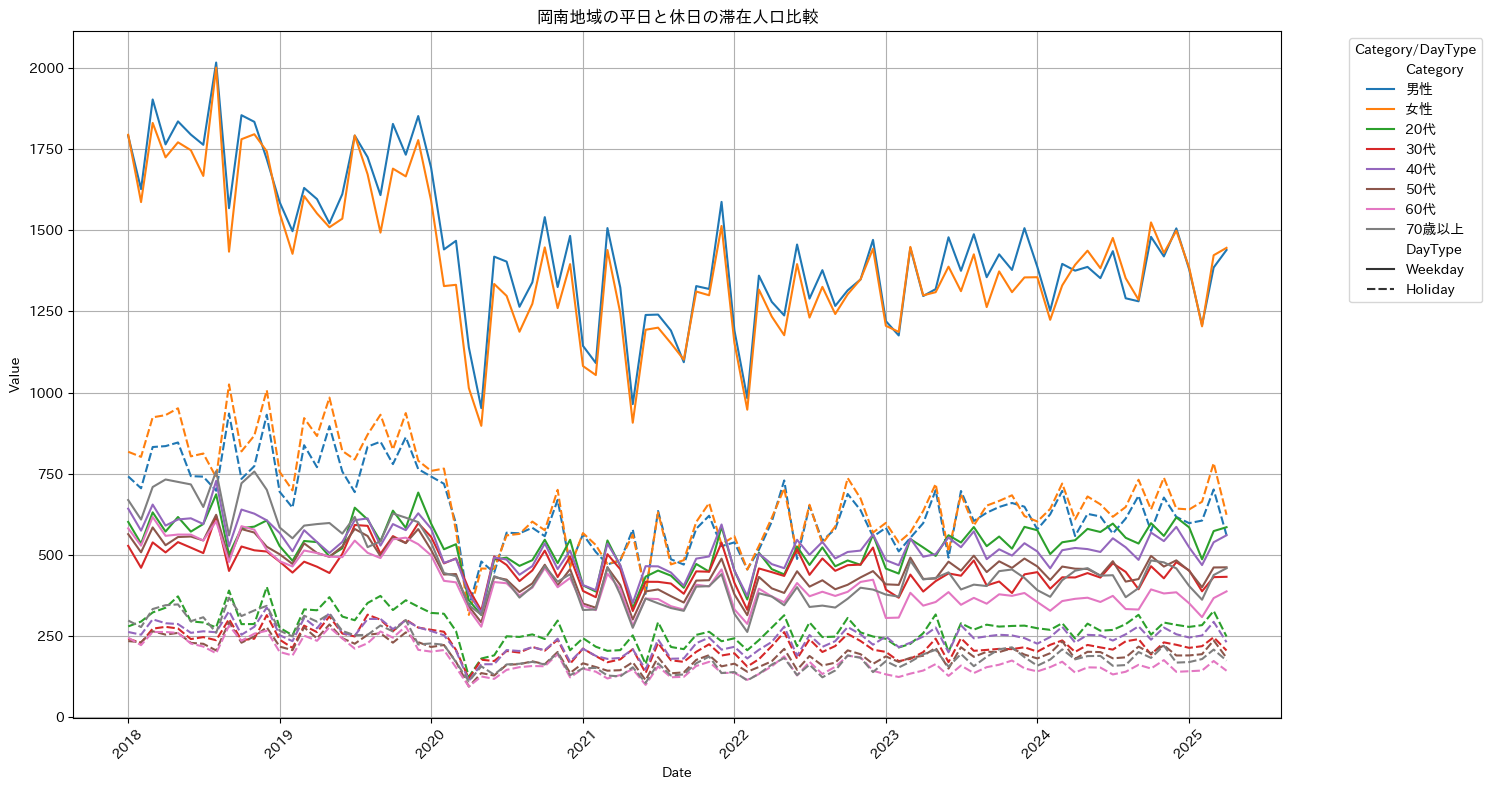

In [30]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=combined_df, x='ds', y='Value', hue='Category', style='DayType')
plt.title('岡南地域の平日と休日の滞在人口比較')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category/DayType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 北長瀬地域の平日と休日の滞在人口比較

In [33]:
kitanagase_df = pd.read_csv('kitanagase_month.csv', encoding="cp932")
kitanagase_df.head()

,北長瀬（都市拠点） 滞在人口（男女別・年代別）,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,北長瀬,NaN,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,NaN,NaN,男性,女性,20代,30代,40代,50代,60代,70歳以上
1,2018年1月,期間全体,470.3,495.7,166.1,176.1,186.7,142.1,133.8,161.2,...,NaN,祝休日,154.2,169,54.6,61.5,67.1,47.9,41.5,50.6
2,2018年2月,期間全体,412.7,434.6,162.7,161.2,171.3,121.3,121.1,109.6,...,NaN,祝休日,136,150.4,51.7,57.6,59.5,43.6,37.1,36.9
3,2018年3月,期間全体,491.3,504.1,192.2,171.8,199.1,131.2,138,163.1,...,NaN,祝休日,169.1,182.2,68.6,64.9,72.8,45.8,39.5,59.8
4,2018年4月,期間全体,464.1,453.7,158.8,167.4,178.4,135.5,137.9,139.7,...,NaN,祝休日,166.1,169.1,60.3,65.5,67.5,51.2,44.7,46


In [34]:
kitanagase_df = kitanagase_df.drop(["Unnamed: 1"], axis=1)

kitanagase_df = kitanagase_df.rename(columns={"Unnamed: 0": "ds"})
kitanagase_df['ds'] = pd.to_datetime(w_df['ds'])
kitanagase_df

,北長瀬（都市拠点） 滞在人口（男女別・年代別）,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,ds
0,北長瀬,男性,女性,20代,30代,40代,50代,60代,70歳以上,NaN,...,NaN,男性,女性,20代,30代,40代,50代,60代,70歳以上,2018-01-01
1,2018年1月,470.3,495.7,166.1,176.1,186.7,142.1,133.8,161.2,NaN,...,祝休日,154.2,169,54.6,61.5,67.1,47.9,41.5,50.6,2018-02-01
2,2018年2月,412.7,434.6,162.7,161.2,171.3,121.3,121.1,109.6,NaN,...,祝休日,136,150.4,51.7,57.6,59.5,43.6,37.1,36.9,2018-03-01
3,2018年3月,491.3,504.1,192.2,171.8,199.1,131.2,138,163.1,NaN,...,祝休日,169.1,182.2,68.6,64.9,72.8,45.8,39.5,59.8,2018-04-01
4,2018年4月,464.1,453.7,158.8,167.4,178.4,135.5,137.9,139.7,NaN,...,祝休日,166.1,169.1,60.3,65.5,67.5,51.2,44.7,46,2018-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,2024年12月,435.5,431.5,127.6,152.1,199,139.5,117.8,131.1,NaN,...,祝休日,137.9,139.7,43.3,53,65.5,45,34.6,36.4,2025-01-01
85,2025年1月,419.6,411.2,128,150.9,188.5,132.5,108.7,122.2,NaN,...,祝休日,141.3,139.3,46.6,54.1,65.3,44.4,34.1,36.2,2025-02-01
86,2025年2月,392.2,380.1,118.6,139.2,170.7,123,103.2,117.5,NaN,...,祝休日,147.8,144.8,48.2,55.6,67.1,46.2,36,39.6,2025-03-01
87,2025年3月,432.5,432.9,133,150.4,194.1,142.8,114.1,131,NaN,...,祝休日,167.2,165.4,56,62.2,75.3,55.5,42.1,41.5,2025-04-01


In [35]:
#折れ線グラフを作成
df_melted_numeric['DayType'] = 'Weekday'
h_df_melted_numeric['DayType'] = 'Holiday'

combined_df = pd.concat([df_melted_numeric, h_df_melted_numeric], ignore_index=True)

print("結合後のデータ")
print(combined_df.head())
print(combined_df.tail())

結合後のデータ
          ds Category   Value  DayType
0 2018-01-01       男性  1791.2  Weekday
1 2018-02-01       男性  1626.6  Weekday
2 2018-03-01       男性  1903.0  Weekday
3 2018-04-01       男性  1764.6  Weekday
4 2018-05-01       男性  1835.4  Weekday
             ds Category  Value  DayType
1403 2024-12-01    70歳以上  167.9  Holiday
1404 2025-01-01    70歳以上  169.5  Holiday
1405 2025-02-01    70歳以上  178.8  Holiday
1406 2025-03-01    70歳以上  208.0  Holiday
1407 2025-04-01    70歳以上  174.1  Holiday


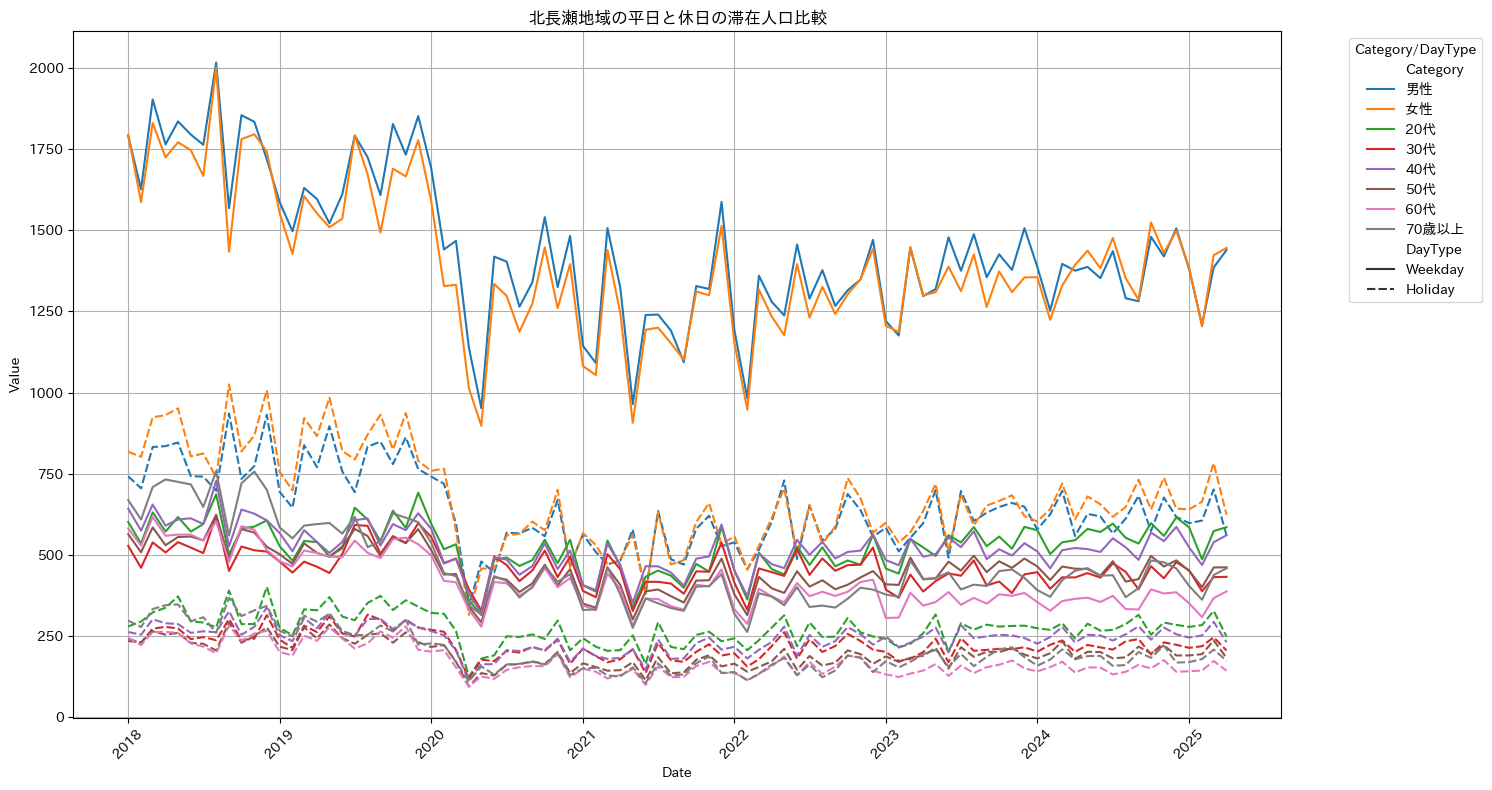

In [36]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=combined_df, x='ds', y='Value', hue='Category', style='DayType')
plt.title('北長瀬地域の平日と休日の滞在人口比較')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category/DayType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 浜・原尾島地域の平日と休日の滞在人口比較

In [37]:
hama_haraojima_df = pd.read_csv('hama_haraojima_month.csv', encoding="cp932")
hama_haraojima_df.head()

,浜・原尾島（都市拠点） 滞在人口（男女別・年代別）,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,浜・原尾島,NaN,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,NaN,NaN,男性,女性,20代,30代,40代,50代,60代,70歳以上
1,2018年1月,期間全体,434.1,552.3,129.9,144.5,175,151.8,202.1,183.1,...,NaN,祝休日,143.1,181.1,41.9,48.9,56.1,50.5,62.2,64.6
2,2018年2月,期間全体,399.2,503.4,124.6,126.9,160,131.3,183.8,175.9,...,NaN,祝休日,131.2,174.8,42,43.4,52.4,44.3,56.6,67.3
3,2018年3月,期間全体,467.7,570.9,154.4,148.8,180.2,155.4,225.1,174.7,...,NaN,祝休日,164.2,194.8,57.7,52.2,57.8,54.2,74.3,62.7
4,2018年4月,期間全体,469.7,566.4,143.9,161.6,174.6,147.4,203.2,205.4,...,NaN,祝休日,168.9,195.8,54.3,59.7,60.7,53.6,68.5,68


In [38]:
hama_haraojima_df = hama_haraojima_df.drop(["Unnamed: 1"], axis=1)

hama_haraojima_df = hama_haraojima_df.rename(columns={"Unnamed: 0": "ds"})
hama_haraojima_df['ds'] = pd.to_datetime(w_df['ds'])
hama_haraojima_df

,浜・原尾島（都市拠点） 滞在人口（男女別・年代別）,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,ds
0,浜・原尾島,男性,女性,20代,30代,40代,50代,60代,70歳以上,NaN,...,NaN,男性,女性,20代,30代,40代,50代,60代,70歳以上,2018-01-01
1,2018年1月,434.1,552.3,129.9,144.5,175,151.8,202.1,183.1,NaN,...,祝休日,143.1,181.1,41.9,48.9,56.1,50.5,62.2,64.6,2018-02-01
2,2018年2月,399.2,503.4,124.6,126.9,160,131.3,183.8,175.9,NaN,...,祝休日,131.2,174.8,42,43.4,52.4,44.3,56.6,67.3,2018-03-01
3,2018年3月,467.7,570.9,154.4,148.8,180.2,155.4,225.1,174.7,NaN,...,祝休日,164.2,194.8,57.7,52.2,57.8,54.2,74.3,62.7,2018-04-01
4,2018年4月,469.7,566.4,143.9,161.6,174.6,147.4,203.2,205.4,NaN,...,祝休日,168.9,195.8,54.3,59.7,60.7,53.6,68.5,68,2018-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,2025年2月,336.9,438.1,92.7,122.3,147.4,124.7,111.9,176,NaN,...,祝休日,122.1,156.9,31.9,45.4,55.4,45.4,39.9,61,2025-03-01
87,2025年3月,397.5,486,103.3,136.1,175.4,145,129.8,193.9,NaN,...,祝休日,146,175.9,37.6,51.9,64.1,53.8,47,67.6,2025-04-01
88,2025年4月,410.5,507.9,127,134.8,184.8,145.4,125.7,200.8,NaN,...,祝休日,129.9,155.5,38.5,44.8,58.3,44.9,39.4,59.5,NaT
89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


In [39]:
#折れ線グラフを作成
df_melted_numeric['DayType'] = 'Weekday'
h_df_melted_numeric['DayType'] = 'Holiday'

combined_df = pd.concat([df_melted_numeric, h_df_melted_numeric], ignore_index=True)

print("結合後のデータ")
print(combined_df.head())
print(combined_df.tail())

結合後のデータ
          ds Category   Value  DayType
0 2018-01-01       男性  1791.2  Weekday
1 2018-02-01       男性  1626.6  Weekday
2 2018-03-01       男性  1903.0  Weekday
3 2018-04-01       男性  1764.6  Weekday
4 2018-05-01       男性  1835.4  Weekday
             ds Category  Value  DayType
1403 2024-12-01    70歳以上  167.9  Holiday
1404 2025-01-01    70歳以上  169.5  Holiday
1405 2025-02-01    70歳以上  178.8  Holiday
1406 2025-03-01    70歳以上  208.0  Holiday
1407 2025-04-01    70歳以上  174.1  Holiday


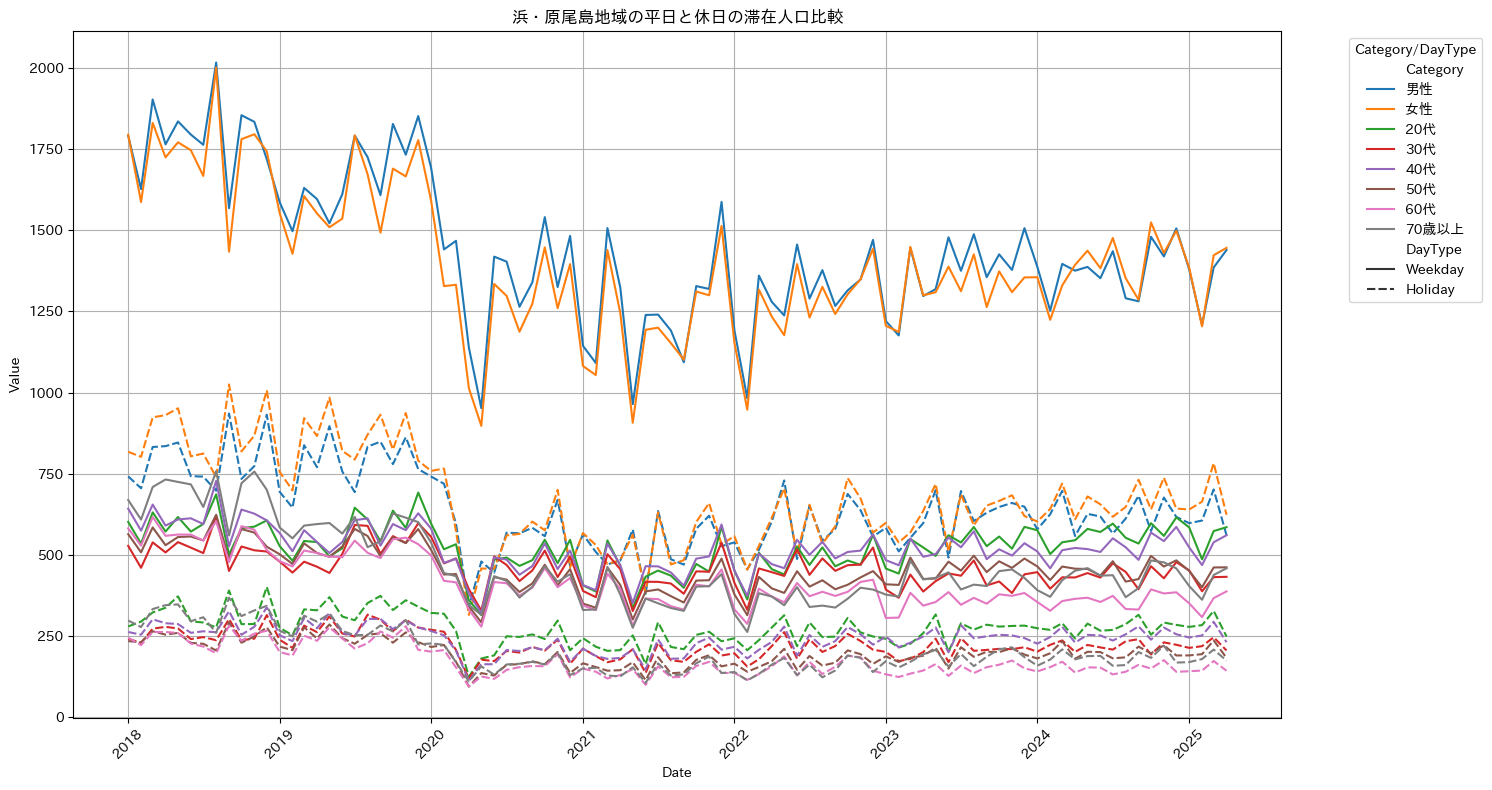

In [40]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=combined_df, x='ds', y='Value', hue='Category', style='DayType')
plt.title('浜・原尾島地域の平日と休日の滞在人口比較')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category/DayType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 西大寺地域の平日と休日の滞在人口比較

In [41]:
saidaiji_df = pd.read_csv('saidaiji_month.csv', encoding="cp932")
saidaiji_df.head()

,西大寺（都市拠点） 滞在人口（男女別・年代別）,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,西大寺,NaN,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,NaN,NaN,男性,女性,20代,30代,40代,50代,60代,70歳以上
1,2018年1月,期間全体,301.8,391.7,56.4,105.6,117,101.6,123.5,189.4,...,NaN,祝休日,95.8,117.7,17.7,33.9,37.7,29.9,37.4,57
2,2018年2月,期間全体,302.5,400.6,53.9,98.7,116.7,103.7,130.7,199.3,...,NaN,祝休日,103.3,123.9,19.6,34.4,40.3,33.5,40.7,58.9
3,2018年3月,期間全体,308.3,409,50.3,111.4,129.4,108.2,131.1,187,...,NaN,祝休日,98.4,133.5,20.4,35.8,41.4,33.8,41.9,58.6
4,2018年4月,期間全体,313.9,421.1,77.8,106.5,122.4,100.8,127.9,199.5,...,NaN,祝休日,106.4,140.8,29.7,35.5,40.3,33.7,40.8,67.1


In [42]:
saidaiji_df = saidaiji_df.drop(["Unnamed: 1"], axis=1)

saidaiji_df = saidaiji_df.rename(columns={"Unnamed: 0": "ds"})
saidaiji_df['ds'] = pd.to_datetime(w_df['ds'])
saidaiji_df

,西大寺（都市拠点） 滞在人口（男女別・年代別）,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,ds
0,西大寺,男性,女性,20代,30代,40代,50代,60代,70歳以上,NaN,...,NaN,男性,女性,20代,30代,40代,50代,60代,70歳以上,2018-01-01
1,2018年1月,301.8,391.7,56.4,105.6,117,101.6,123.5,189.4,NaN,...,祝休日,95.8,117.7,17.7,33.9,37.7,29.9,37.4,57,2018-02-01
2,2018年2月,302.5,400.6,53.9,98.7,116.7,103.7,130.7,199.3,NaN,...,祝休日,103.3,123.9,19.6,34.4,40.3,33.5,40.7,58.9,2018-03-01
3,2018年3月,308.3,409,50.3,111.4,129.4,108.2,131.1,187,NaN,...,祝休日,98.4,133.5,20.4,35.8,41.4,33.8,41.9,58.6,2018-04-01
4,2018年4月,313.9,421.1,77.8,106.5,122.4,100.8,127.9,199.5,NaN,...,祝休日,106.4,140.8,29.7,35.5,40.3,33.7,40.8,67.1,2018-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,2024年12月,295.5,350.7,87.5,74.6,88.4,106.1,97.8,191.7,NaN,...,祝休日,80.2,94.7,24.2,19.7,24.9,29.2,26.6,50.3,2025-01-01
85,2025年1月,280.7,343.7,80.5,72.6,94.2,100.9,92.2,184.1,NaN,...,祝休日,85,102,26.1,21.4,30.3,30.5,26.1,52.5,2025-02-01
86,2025年2月,270.4,326.2,72.8,77.6,90,97.1,90.1,169,NaN,...,祝休日,93.7,107.4,24.8,26.7,31,33.9,29.8,54.9,2025-03-01
87,2025年3月,289.5,355.5,75.2,74.7,102.1,107.3,99.1,186.6,NaN,...,祝休日,96,115.4,23.6,25.5,34.3,36.9,32.3,58.8,2025-04-01


In [43]:
#折れ線グラフを作成
df_melted_numeric['DayType'] = 'Weekday'
h_df_melted_numeric['DayType'] = 'Holiday'

combined_df = pd.concat([df_melted_numeric, h_df_melted_numeric], ignore_index=True)

print("結合後のデータ")
print(combined_df.head())
print(combined_df.tail())

結合後のデータ
          ds Category   Value  DayType
0 2018-01-01       男性  1791.2  Weekday
1 2018-02-01       男性  1626.6  Weekday
2 2018-03-01       男性  1903.0  Weekday
3 2018-04-01       男性  1764.6  Weekday
4 2018-05-01       男性  1835.4  Weekday
             ds Category  Value  DayType
1403 2024-12-01    70歳以上  167.9  Holiday
1404 2025-01-01    70歳以上  169.5  Holiday
1405 2025-02-01    70歳以上  178.8  Holiday
1406 2025-03-01    70歳以上  208.0  Holiday
1407 2025-04-01    70歳以上  174.1  Holiday


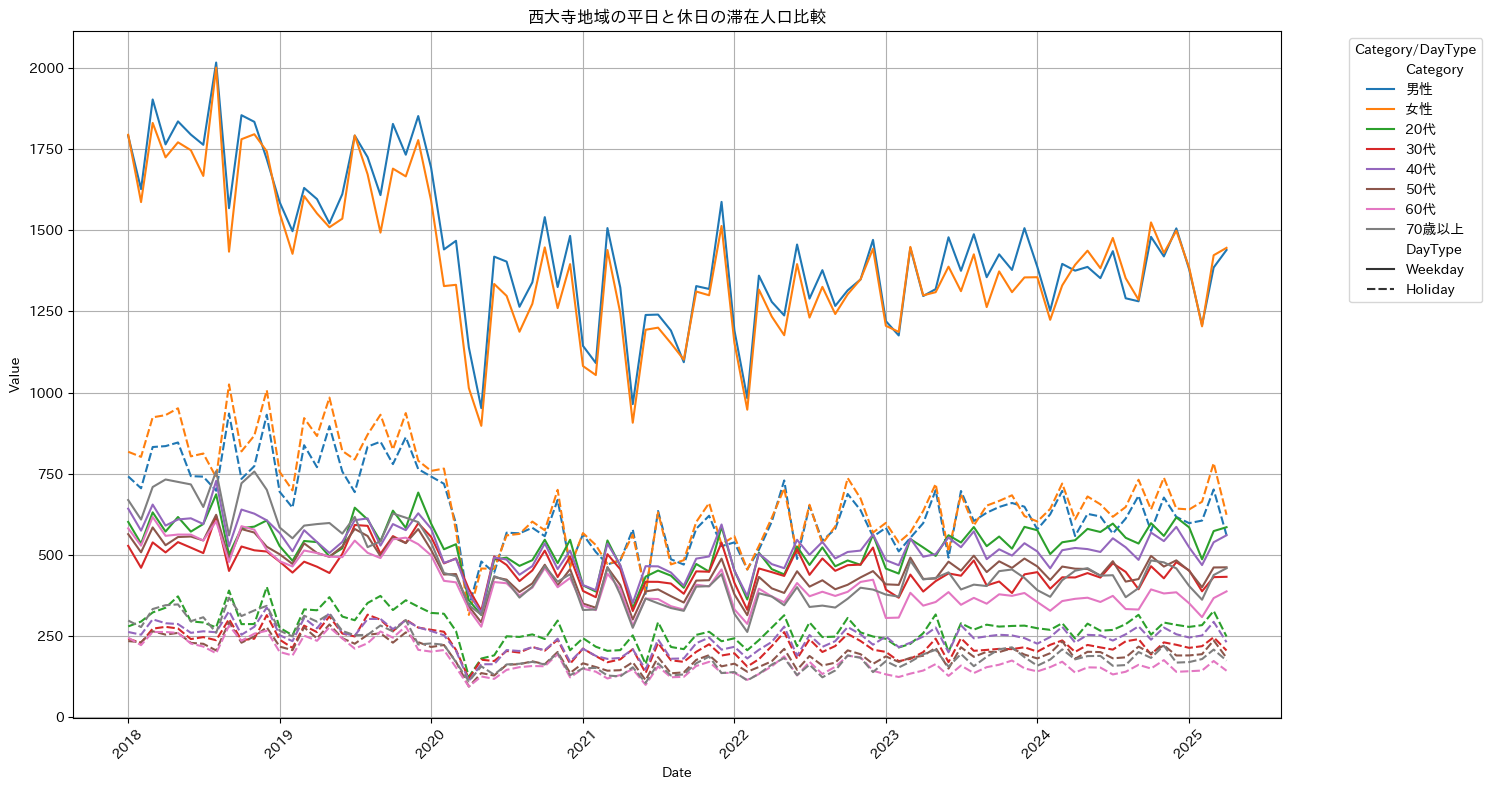

In [46]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=combined_df, x='ds', y='Value', hue='Category', style='DayType')
plt.title('西大寺地域の平日と休日の滞在人口比較')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category/DayType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()